In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.utils import io

# Step 2: Get the absolute path to the src folder and add it to the system path
# Assuming you are running the notebook from the project root directory
models_path = os.path.abspath(os.path.join('..', 'models'))
sys.path.append(models_path)

from model_bkt import ModelBKT


In [2]:
with open('../data/preprocessed/assistments_skill_dict.json', 'r') as json_file:
    skill_dict = json.load(json_file)

In [4]:
min_num_user_answers = 10
min_max_len_user_answer = 3

results = []

for skill_id, user_answers in tqdm(skill_dict.items(), desc="Processing skills"):

    max_len_user_answer = max(len(user_answer) for user_answer in user_answers)
    
    if len(user_answers) >= min_num_user_answers and max_len_user_answer >= min_max_len_user_answer:
        model = ModelBKT(skill_id, user_answers)
        # Suppress output during fit
        with io.capture_output() as captured:
            model.fit()
        auc = model.self_evaluate()  # Evaluate model
        results.append({"skill_id": skill_id, "auc": auc})


Processing skills: 100%|██████████| 123/123 [06:29<00:00,  3.16s/it]


Total number of valid skills: 110


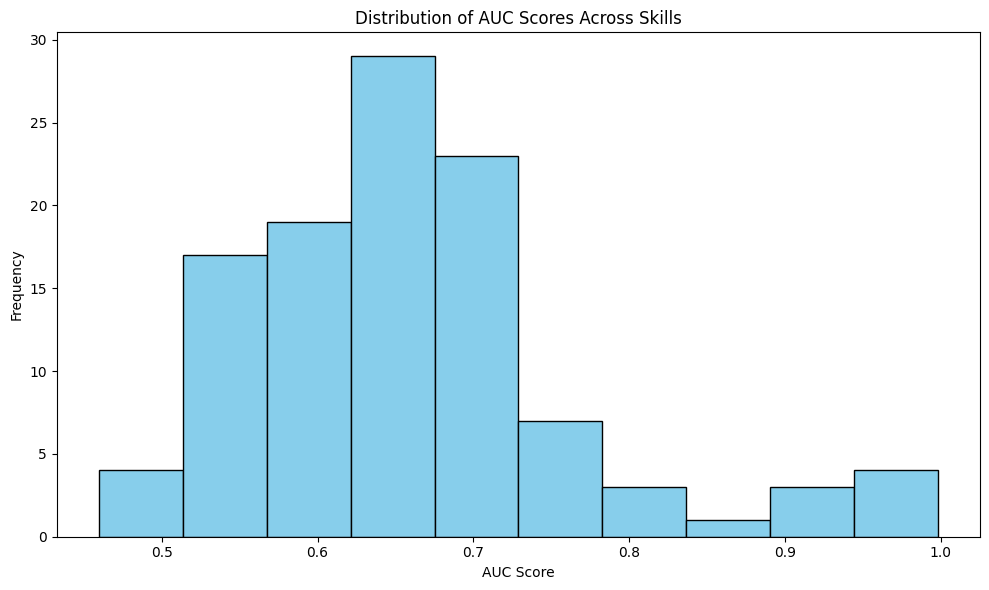

Average AUC across all skills: 0.6576


In [5]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the total number of valid skills
print(f"Total number of valid skills: {len(results_df)}")

# Plot a histogram of AUC scores
plt.figure(figsize=(10, 6))
plt.hist(results_df["auc"], bins=10, color="skyblue", edgecolor="black")
plt.xlabel("AUC Score")
plt.ylabel("Frequency")
plt.title("Distribution of AUC Scores Across Skills")
plt.tight_layout()
plt.show()

# Report the average AUC
average_auc = results_df["auc"].mean()
print(f"Average AUC across all skills: {average_auc:.4f}")

![AUC Scores from the Stanford Paper](./../sources/AUC_results.png)


Our average AUC score is above the Marginal 62% and fairly close to the 67% mentioned in the paper.